In [1]:
!pip install pandas matplotlib openpyxl

In [2]:
import pandas as pd

data = {
    'Name':['John','Mary','John','Alex',None],
    'Age':[25,None,25,30,22],
    'Salary':[50000,60000,50000,None,45000]
}

df = pd.DataFrame(data)

df.to_csv("employee_data.csv",index=False)

df

,Name,Age,Salary
0,John,25.0,50000.0
1,Mary,NaN,60000.0
2,John,25.0,50000.0
3,Alex,30.0,NaN
4,None,22.0,45000.0


In [3]:
import pandas as pd

df = pd.read_csv("employee_data.csv")

print(df)

   Name   Age   Salary
0  John  25.0  50000.0
1  Mary   NaN  60000.0
2  John  25.0  50000.0
3  Alex  30.0      NaN
4   NaN  22.0  45000.0


In [4]:
print(df.isnull().sum())

Name      1
Age       1
Salary    1
dtype: int64


In [5]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

df['Salary'].fillna(df['Salary'].mean(), inplace=True)

df['Name'].fillna("Unknown", inplace=True)

/tmp/ipykernel_2335/1904520798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_2335/1904520798.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
df = df.drop_duplicates()

print(df)

      Name   Age   Salary
0     John  25.0  50000.0
1     Mary  25.5  60000.0
3     Alex  30.0  51250.0
4  Unknown  22.0  45000.0


In [7]:
report = {
    "Total Rows": len(df),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows Removed": "Yes"
}

print(report)

{'Total Rows': 4, 'Missing Values': np.int64(0), 'Duplicate Rows Removed': 'Yes'}


In [8]:
df.to_csv(
    "cleaned_employee_data.csv",
    index=False
)

print("Cleaned file saved")

Cleaned file saved


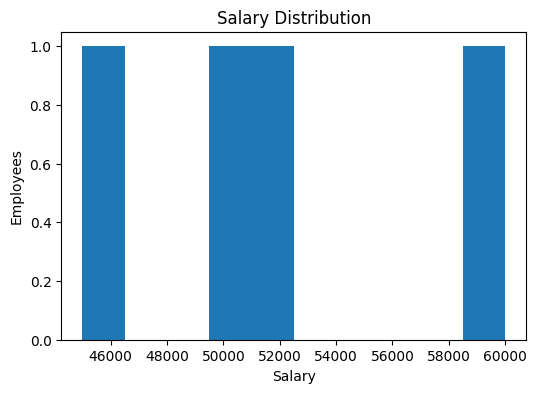

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(df['Salary'])

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Employees")

plt.show()

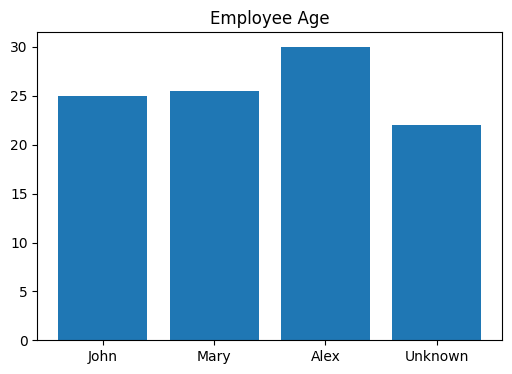

In [10]:
plt.figure(figsize=(6,4))

plt.bar(
    df['Name'],
    df['Age']
)

plt.title("Employee Age")

plt.show()

In [11]:
summary = df.describe()

summary

,Age,Salary
count,4.000000,4.000000
mean,25.625000,51562.500000
std,3.300884,6239.574638
min,22.000000,45000.000000
25%,24.250000,48750.000000
50%,25.250000,50625.000000
75%,26.625000,53437.500000
max,30.000000,60000.000000


In [12]:
with pd.ExcelWriter(
    "Automation_Report.xlsx"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Cleaned Data",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary"
    )

print("Report Generated")

Report Generated
